# 0. Connect Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Import Libraries

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.backend import clear_session

# 2. Load Split Dataset

In [2]:
import sys

project_dir = "/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification"
sys.path.append(project_dir)

from utils import load_animals10_datasets

train_dataset, val_dataset, test_dataset, class_names = load_animals10_datasets()

Using Colab cache for faster access to the 'animals10' dataset.


### Check Data

In [3]:
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels.shape)

print(class_names)

(32, 128, 128, 3)
(32, 10)
['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


# 3. Define Model

In [4]:
from keras.backend import clear_session
clear_session()

In [5]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

num_classes = 10
input_shape= (128, 128, 3)

model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3,3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Conv2D(64, kernel_size=(3,3), activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),
        layers.Flatten(),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       576,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 595,402 (2.27 MB)

 Trainable params: 595,402 (2.27 MB)

 Non-trainable params: 0 (0.00 B)

# 4. Compile and Train Model

In [6]:
from keras.optimizers import Adam

epochs = 30
my_opt = Adam(learning_rate=0.0001)

model.compile(
    loss="categorical_crossentropy",
    optimizer=my_opt,
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=[early_stop]
)

Epoch 1/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 73s 104ms/step - accuracy: 0.3629 - loss: 1.8261 - val_accuracy: 0.4645 - val_loss: 1.5849
Epoch 2/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 27s 41ms/step - accuracy: 0.4943 - loss: 1.4950 - val_accuracy: 0.5164 - val_loss: 1.4442
Epoch 3/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 28s 43ms/step - accuracy: 0.5548 - loss: 1.3382 - val_accuracy: 0.5512 - val_loss: 1.3378
Epoch 4/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 28s 42ms/step - accuracy: 0.5976 - loss: 1.2265 - val_accuracy: 0.5611 - val_loss: 1.2973
Epoch 5/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - accuracy: 0.6320 - loss: 1.1319 - val_accuracy: 0.5783 - val_loss: 1.2598
Epoch 6/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - accuracy: 0.6608 - loss: 1.0489 - val_accuracy: 0.5814 - val_loss: 1.2502
Epoch 7/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.6855 - loss: 0.9787 - val_accuracy: 0.6050 - val_loss: 1.1989
Epoch 8/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.7089 - loss: 0.9146 -

In [ ]:
# tract train time

# 5. Evaluate Model

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    true_labels = np.argmax(labels.numpy(), axis=1)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(true_labels)
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall = recall_score(y_true, y_pred, average="macro", zero_division=0)

print("Test accuracy:", accuracy)
print("Test precision:", precision)
print("Test recall:", recall)

Test accuracy: 0.586707410236822
Test precision: 0.5613280752557824
Test recall: 0.5362323146905474


# 5.2 Confusion Matrix

# 6.Plot Loss and Accuracy Curves

In [7]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

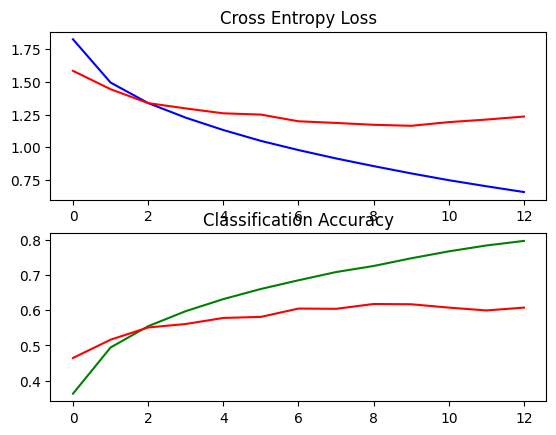

In [9]:
import matplotlib.pyplot as plt

plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(history.history['loss'], color='blue', label='train')
plt.plot(history.history['val_loss'], color='red', label='validation')

plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(history.history['accuracy'], color='green', label='train')
plt.plot(history.history['val_accuracy'], color='red', label='validation')
plt.show()

# 7. Save Model

In [12]:
model.save("/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification/saved_models/baseline_model.keras")

print("Model Saved")

Model Saved


In [ ]:
# how to import model when needed

'''
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification/saved_models/baseline_model.keras"
)
'''